<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

Cloning into 'IntroToAI_A2'...
remote: Enumerating objects: 3652, done.
remote: Counting objects: 100% (3652/3652), done.
remote: Compressing objects: 100% (2463/2463), done.
remote: Total 3652 (delta 1249), reused 3578 (delta 1188), pack-reused 0 (from 0)
Receiving objects: 100% (3652/3652), 2.05 MiB | 9.99 MiB/s, done.
Resolving deltas: 100% (1249/1249), done.
/content/IntroToAI_A2


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

loading in dataset for training

In [9]:
train_df = pd.read_csv('TrainDataset1/all_features.csv', header=None)

task 3.1

Best Parameters: {'max_features': 4, 'n_estimators': 375}
Best CV Accuracy: 0.9338


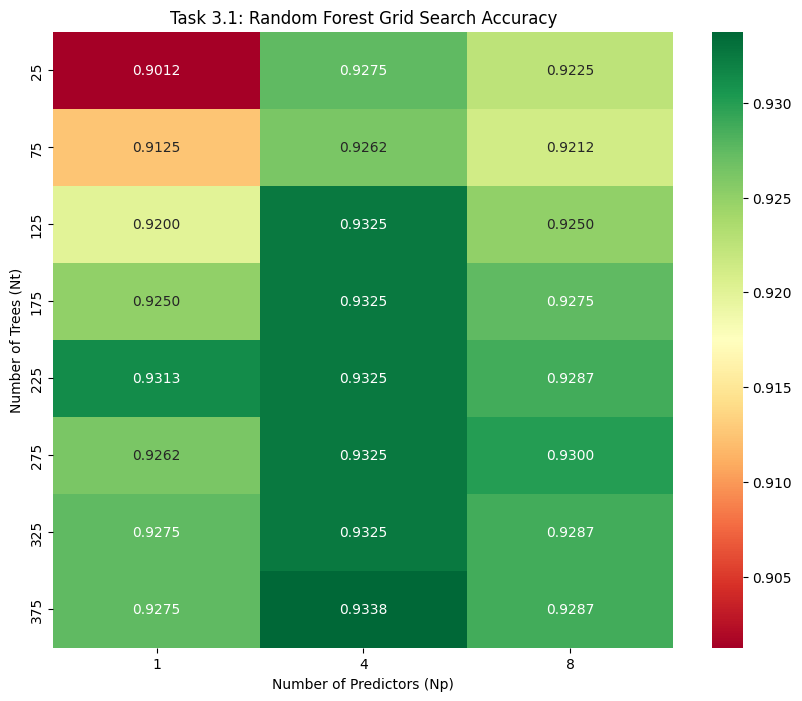

In [10]:
# 2. Separate Class Labels from Features
# Column 0 is the Class Label (y)
# Columns 2 to 17 are the numeric Features (X)
y = train_df.iloc[:, 0]
X = train_df.iloc[:, 2:]

# 3. Define Grid Search parameters
# Nt: 25 to 375 (increments of 50)
# Np: 1, 4, 8
param_grid = {
    'n_estimators': [25, 75, 125, 175, 225, 275, 325, 375],
    'max_features': [1, 4, 8]
}

# 4. Initialize Random Forest and Run 5-fold CV Grid Search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

# 5. Extract results and visualize
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot(index='param_n_estimators', columns='param_max_features', values='mean_test_score')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='RdYlGn')
plt.title('Task 3.1: Random Forest Grid Search Accuracy')
plt.xlabel('Number of Predictors (Np)')
plt.ylabel('Number of Trees (Nt)')
plt.savefig('task_3_1_heatmap.png')

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")